# Build and train MicNet


In [13]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage

import time
import torch
import torch.hub
import torch.nn
import tifffile

from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion

## 1) Load data

(41048, 30035, 3)


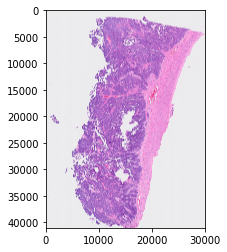

In [18]:
image_file = "./Sample_data/Dataset_HOC/5_CytAssist_11mm_FFPE_Human_Ovarian_Carcinoma_tissue_image.tif"

image = tifffile.imread(image_file)
print(image.shape)
image_norm = image.copy()
plt.imshow(image)
plt.show()

In [6]:
count_stat = pd.read_csv("./output/Dataset_HOC/1_count_stat_ovarian.csv", index_col=0)
count = pd.read_csv("./output/Dataset_HOC/1_pd_count_norm_ovarian.csv", index_col=0)

In [7]:
pd_meta = pd.read_csv('./Sample_data/Dataset_HOC/meta_df.csv', index_col=0)

pd_meta = pd_meta[['pxl_row_in_fullres', 'pxl_col_in_fullres']].copy()
pd_meta.columns = ['X', 'Y']

pd_meta

,X,Y
barcode,,
AACAATGTGCTCCGAG-1,29958,4830
AACACCATTCGCATAC-1,15758,8366
AACACGTTGATACCGC-1,25910,17813
AACACTCGTGAGCTTC-1,27140,10504
AACAGCCTCCTGACTA-1,31887,12125
...,...,...
TGTTGCTATCGGTGGC-1,39153,12639
TGTTGGCCTGTAGCGG-1,11706,19523
TGTTGGTGCGCACGAG-1,6626,14069


In [8]:
# Split training and testing
np.random.seed(82321)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.8), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 3739, #Testing: 935


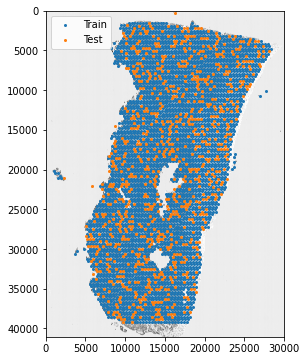

In [20]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm[..., 0], cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Y"].values
coords_y = pd_meta.loc[training_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Y"].values
coords_y = pd_meta.loc[testing_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [21]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [22]:
count

,EMC10,ARHGEF28,NUDT2,ITPR3,TMEM151B,CSKMT,DYNLL1,CENPQ,MSH6,HTR2B,...,CYTH4,SNAPC3,TYMP,CPTP,WBP2,OR7C2,SV2B,HSPA14,TBCE,TMSB15B
AACAATGTGCTCCGAG-1,0.577714,0.000000,0.000000,0.709529,0.000000,0.556307,0.000000,0.598244,0.726870,0.000000,...,0.000000,0.517354,0.000000,0.709155,0.582289,0.000000,0.0,0.720520,0.700419,0.603897
AACACCATTCGCATAC-1,0.518919,0.000000,0.640593,0.747078,0.000000,0.000000,0.000000,0.638735,0.662558,0.000000,...,0.000000,0.552371,0.671911,0.582444,0.000000,0.000000,0.0,0.607465,0.000000,0.000000
AACACGTTGATACCGC-1,0.699717,0.000000,0.545101,0.735134,0.000000,0.505420,0.687527,0.543520,0.736323,0.000000,...,0.514083,0.624173,0.404326,0.762166,0.445062,0.000000,0.0,0.713477,0.685950,0.000000
AACACTCGTGAGCTTC-1,0.732488,0.465871,0.527088,0.718204,0.000000,0.000000,0.628785,0.637155,0.761786,0.467891,...,0.000000,0.454497,0.585601,0.581003,0.430354,0.543997,0.0,0.698443,0.769393,0.000000
AACAGCCTCCTGACTA-1,0.678643,0.616983,0.631762,0.830263,0.000000,0.647240,0.622278,0.629930,0.613170,0.560809,...,0.595812,0.741456,0.385706,0.634691,0.424566,0.000000,0.0,0.600274,0.666578,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGCTATCGGTGGC-1,0.740215,0.505666,0.000000,0.623040,0.000000,0.000000,0.610533,0.000000,0.601598,0.000000,...,0.000000,0.648020,0.642411,0.810693,0.467115,0.000000,0.0,0.697503,0.729185,0.579940
TGTTGGCCTGTAGCGG-1,0.690938,0.453720,0.513339,0.775930,0.000000,0.475970,0.616158,0.000000,0.766365,0.455686,...,0.000000,0.694437,0.380767,0.732245,0.510256,0.000000,0.0,0.648594,0.598563,0.000000
TGTTGGTGCGCACGAG-1,0.663483,0.000000,0.000000,0.641153,0.000000,0.653485,0.628282,0.000000,0.719454,0.000000,...,0.664686,0.000000,0.522775,0.744705,0.000000,0.000000,0.0,0.659631,0.000000,0.000000
TGTTGGTGCGGAATCA-1,0.599781,0.554076,0.626882,0.757610,0.547061,0.000000,0.558831,0.513733,0.682690,0.556477,...,0.000000,0.718113,0.464987,0.734030,0.420671,0.000000,0.0,0.688510,0.720861,0.000000


In [23]:
PATCH_SIZE = 256

## 2) Check data loader

In [24]:
# from utils_data import Dataset
from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Y"], self.meta_df.loc[indexes, "X"]], 
                                PATCH_SIZE)  # meta_df mistakes X/Y
        if self.augmentation:
            image = augmentor(normalize(image))
        else:
            image = normalize(image)
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

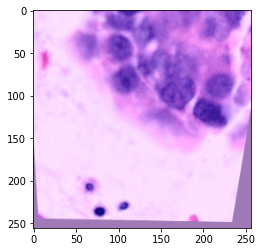

tensor([571])


In [25]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

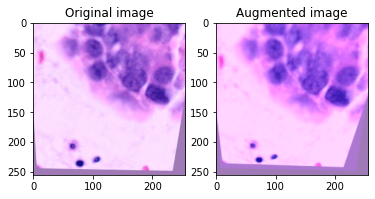

In [26]:
image = normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True)
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

## 3) Create network

In [28]:
from torch.nn.modules import MSELoss

device = torch.device("cuda:0")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters

nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters

lr = 0.01   
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[500, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

In [29]:
model_dir = "./models/Dataset_HPC"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [30]:
model

MicNet(
  (imagenet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          

In [19]:
"""TO LOAD:"""
model_file = None
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

## 4) Train

In [20]:
import time
from scipy.stats import spearmanr

from utils_eval import AverageMeter

def train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:1")):
    """
    One epoch training
    """
    model.train()
    contrast.train()

    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    image_loss_meter = AverageMeter()
    gene_loss_meter = AverageMeter()
    image_prob_meter = AverageMeter()
    gene_prob_meter = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(train_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        out_image, out_gene = contrast(feat_image, feat_gene, index)
        
        # print("features:", feat_image, feat_gene, "\n")
        # print("outs: ", out_image, out_gene, "\n")
        
        image_loss = criterion_image(out_image)
        gene_loss = criterion_gene(out_gene)
        image_prob = out_image[:, 0].mean()
        gene_prob = out_gene[:, 0].mean()

        loss = image_loss + gene_loss

        # ===================backward=====================
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        torch.nn.utils.clip_grad_norm_(contrast.parameters(), gradient_clip)
        optimizer.step()

        # ===================meters=====================
        losses.update(loss.item(), batch_size)
        image_loss_meter.update(image_loss.item(), batch_size)
        image_prob_meter.update(image_prob.item(), batch_size)
        gene_loss_meter.update(gene_loss.item(), batch_size)
        gene_prob_meter.update(gene_prob.item(), batch_size)

        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()

        # print info
        if (idx + 1) % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t'

                  'loss {loss.val:.3f} ({loss.avg:.3f})\t'
                  'image_p {image_probs.val:.3f} ({image_probs.avg:.3f})\t'
                  'gene_p {gene_probs.val:.3f} ({gene_probs.avg:.3f})'.format(
                   epoch, idx + 1, len(train_loader), batch_time=batch_time,
                   data_time=data_time, 
                   loss=losses, 
                   image_probs=image_prob_meter,
                   gene_probs=gene_prob_meter))
            # print(out_image.shape)
            sys.stdout.flush()
            
        # ===================debug======================
        if np.isnan(image_prob_meter.val):
            print(list(model.parameters()))
            print(feat_image)
            print(feat_gene)
            print(out_image)
            
            raise Exception("Nan detected")
            break

    return losses.avg, image_loss_meter.avg, image_prob_meter.avg, gene_loss_meter.avg, gene_prob_meter.avg


def test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:1")):
    """Testing"""
    model.eval()
    contrast.eval()

    batch_time = AverageMeter()
    data_time = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(test_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        with torch.no_grad():
            feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])
        
        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()
        
    # Normalize & calculate correlation
    feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
    feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
    corr = []
    for i in range(feat_images.shape[1]):
        corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
    if epoch % 100 == 0:
        plt.hist(corr, bins=30)
        plt.show()
    print("Val epoch {}, average corr {}".format(epoch, np.average(corr)))

    return np.average(corr)

Epoch: [0][10/187]	loss 60.925 (63.791)	image_p 0.011 (0.010)	gene_p 0.010 (0.010)
Epoch: [0][20/187]	loss 48.310 (58.293)	image_p 0.001 (0.011)	gene_p 0.012 (0.010)
Epoch: [0][30/187]	loss 49.149 (55.246)	image_p 0.000 (0.010)	gene_p 0.008 (0.010)
Epoch: [0][40/187]	loss 48.946 (53.743)	image_p 0.000 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][50/187]	loss 44.741 (52.292)	image_p 0.013 (0.009)	gene_p 0.017 (0.010)
Epoch: [0][60/187]	loss 45.523 (51.187)	image_p 0.000 (0.009)	gene_p 0.008 (0.010)
Epoch: [0][70/187]	loss 43.049 (50.148)	image_p 0.008 (0.010)	gene_p 0.009 (0.010)
Epoch: [0][80/187]	loss 41.392 (48.964)	image_p 0.017 (0.010)	gene_p 0.035 (0.011)
Epoch: [0][90/187]	loss 35.877 (47.631)	image_p 0.001 (0.009)	gene_p 0.013 (0.012)
Epoch: [0][100/187]	loss 32.999 (46.255)	image_p 0.025 (0.011)	gene_p 0.014 (0.013)
Epoch: [0][110/187]	loss 29.308 (44.992)	image_p 0.043 (0.012)	gene_p 0.047 (0.013)
Epoch: [0][120/187]	loss 27.593 (43.707)	image_p 0.006 (0.012)	gene_p 0.017 (0.014)
E

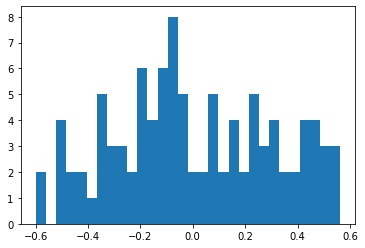

Val epoch 0, average corr 0.00514885994323848
Epoch: [1][10/187]	loss 37.138 (35.760)	image_p 0.000 (0.007)	gene_p 0.000 (0.003)
Epoch: [1][20/187]	loss 32.027 (33.714)	image_p 0.000 (0.011)	gene_p 0.000 (0.005)


In [ ]:
hist = dict()
hist['loss'] = []
hist['corr_val'] = []
hist['image_loss'] = []
hist['image_prob'] = []
hist['gene_loss'] = []
hist['gene_prob'] = []

save_freq = 10
best_corr = -float("inf")

for epoch in range(1000):
    loss, image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['loss'].append(loss)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    
    corr = test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['corr_val'].append(corr)
    metric = image_loss + gene_loss
    # Check if this is the best corr so far
    if corr > best_corr:
        best_corr = corr
        hist_best = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'corr_val': corr
        }
        torch.save(hist_best, os.path.join(model_dir, "epoch_best.pt"))
        
    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch }
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

In [ ]:
torch.save(hist, os.path.join(model_dir, "hist.pt"))

# Session Info

In [58]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2019.3.9
chardet==3.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==2.8
image-registration==0.2.4
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel==5.1.0
ipython==7.4.0
ipython-genutils==0.2.0
ipywidgets==7.4.2
isodate==0.6.0
jedi==0.13.3
Jinj